# 1. EDA

### 1.1  Setup & imports

In [122]:
import pandas as pd
from pathlib import Path
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, brier_score_loss,
    ConfusionMatrixDisplay
)
import joblib
RANDOM_SEED = 42

### 1.2 Loading the dataset


In [123]:
df = pd.read_csv("../Dataset/clean/interactions_clean.csv")

### 1.3 Data exploration

In [124]:
df.shape

(17340, 6)

In [125]:
df.head()

,Student ID,Question ID,difficulty,correct,Response Time,topic
0,AQklHbi5bt8l,1,hard,0,27232,Data Mining Tasks
1,AQklHbi5bt8l,2,easy,1,8933,Similarity Measures
2,AQklHbi5bt8l,3,easy,1,14965,Similarity Measures
3,AQklHbi5bt8l,4,easy,1,12691,Similarity Measures
4,AQklHbi5bt8l,5,medium,0,26452,Similarity Measures


In [126]:
df.dtypes

Student ID       object
Question ID       int64
difficulty       object
correct           int64
Response Time     int64
topic            object
dtype: object

- unique values in each column

In [127]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

Student ID: 121
Question ID: 150
difficulty: 3
correct: 2
Response Time: 3884
topic: 25


- unique topics

In [128]:
df["topic"].unique()

array(['Data Mining Tasks', 'Similarity Measures', 'Time Series Data',
       'Data Types', 'Programming Tools (NumPy/Pandas)',
       'Unsupervised Learning', 'Data Preprocessing',
       'Scaling & Normalization', 'Feature Selection',
       'Feature Extraction', 'Principal Component Analysis',
       'Decision Trees', 'K-means Clustering', 'Hierarchical Clustering',
       'DBSCAN', 'Model Evaluation', 'Clustering Evaluation',
       'Classification', 'Overfitting & Regularization',
       'Cross-Validation', 'Association Rules', 'Apriori Algorithm',
       'FP-growth', 'Rule Metrics', 'General'], dtype=object)

- distribution of each value

In [129]:
topic_counts = df["topic"].value_counts()
print (topic_counts)

topic
Decision Trees                      2394
Association Rules                   1792
Data Types                          1625
Principal Component Analysis        1428
Feature Selection                   1309
DBSCAN                               936
K-means Clustering                   932
Similarity Measures                  819
Unsupervised Learning                814
Hierarchical Clustering              585
Model Evaluation                     577
Data Mining Tasks                    472
Programming Tools (NumPy/Pandas)     468
Overfitting & Regularization         452
Classification                       452
Cross-Validation                     339
Apriori Algorithm                    336
Rule Metrics                         336
Clustering Evaluation                234
Data Preprocessing                   234
Scaling & Normalization              234
FP-growth                            224
Feature Extraction                   119
Time Series Data                     117
General   

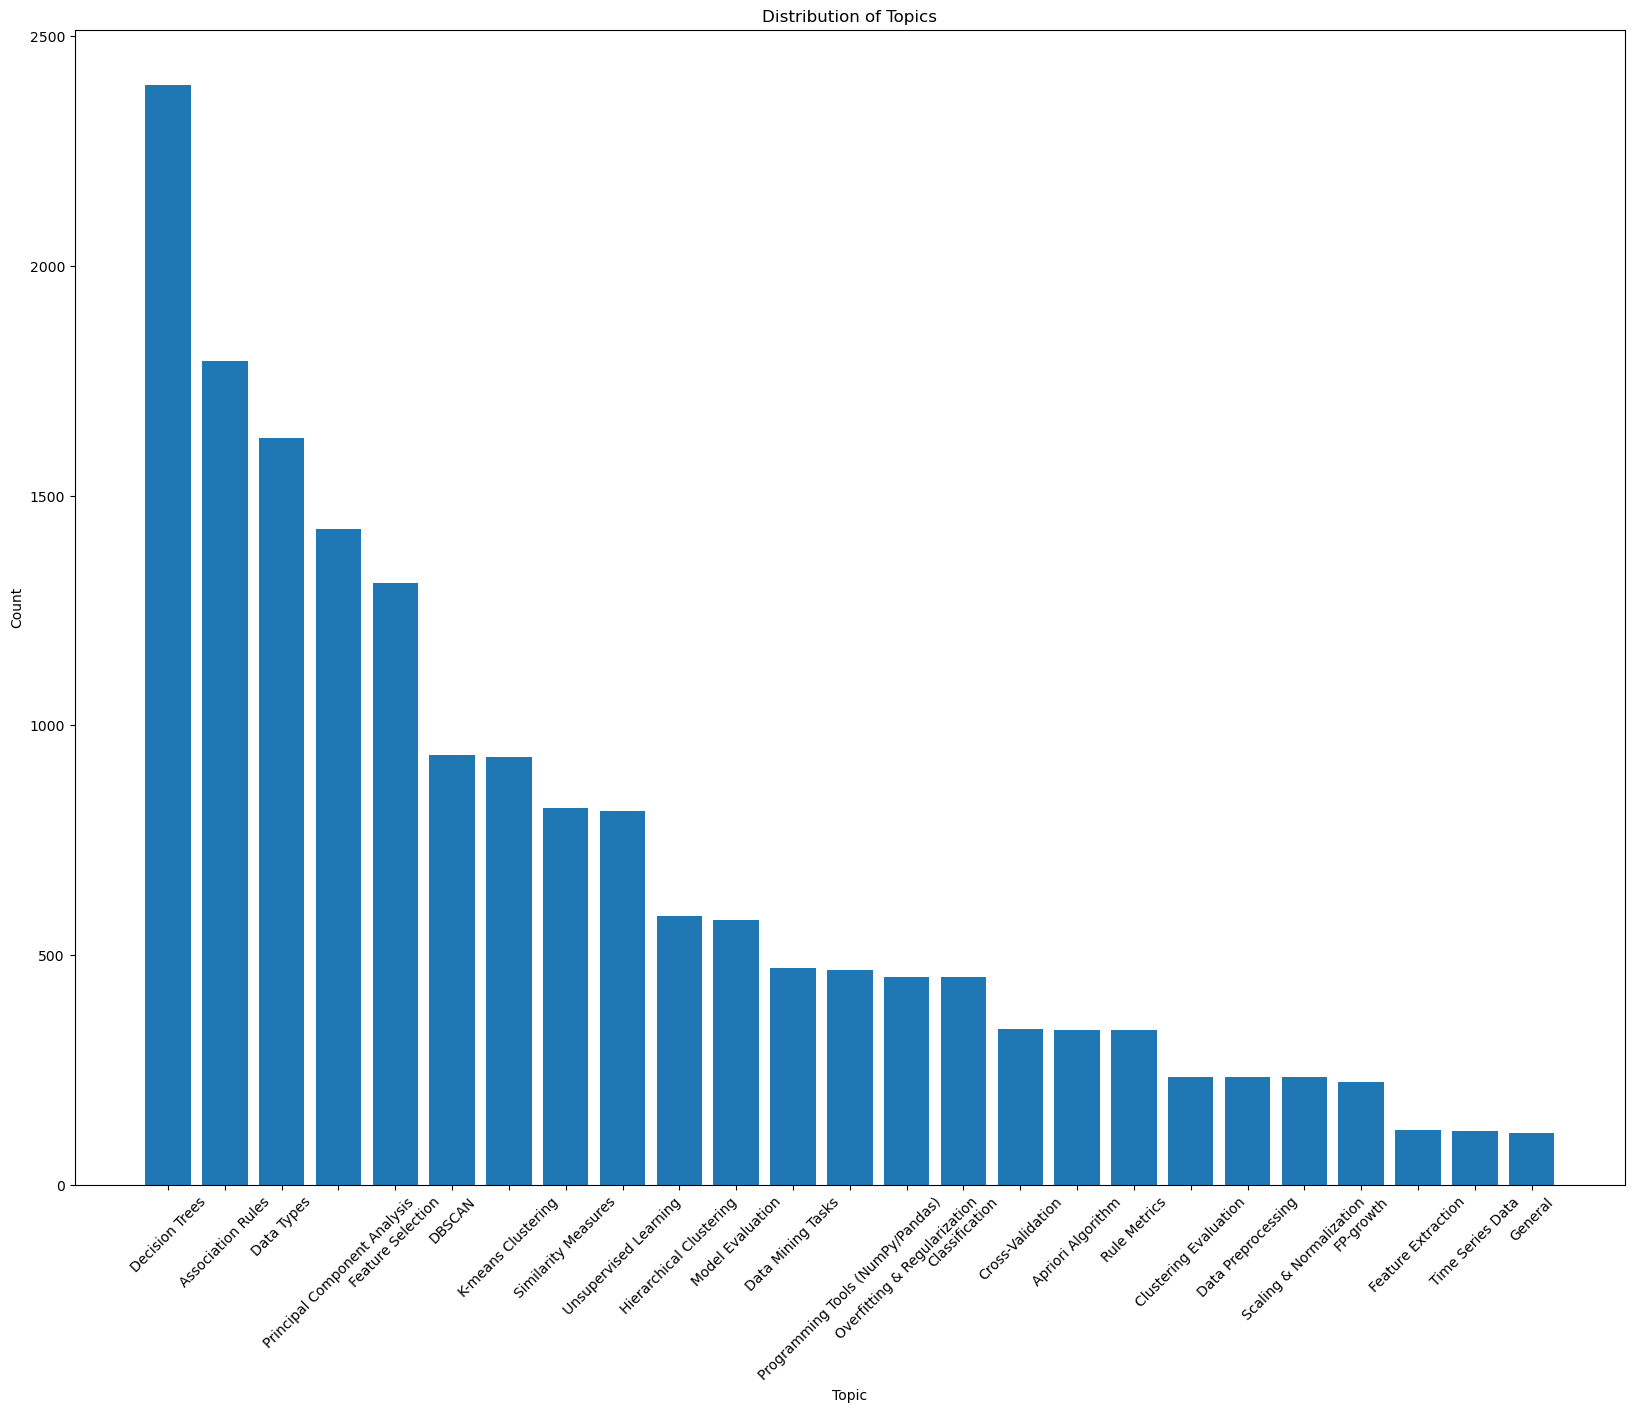

In [130]:
# vizualize the distribution of topics
topic_counts = df["topic"].value_counts()
plt.figure(figsize=(20, 15))
plt.bar(topic_counts.index, topic_counts.values)
plt.xlabel("Topic")
plt.ylabel("Count")
plt.title("Distribution of Topics")
plt.xticks(rotation=45)
plt.show()

- distribution of correct/incorrect

In [131]:
correct_counts = df["correct"].value_counts()
correct_percent = (correct_counts / len(df) * 100).round(2)
print(pd.DataFrame({"count": correct_counts, "percent": correct_percent}))

         count  percent
correct                
1        13134    75.74
0         4206    24.26


- Diffuculty distribution

In [132]:
difficulty_counts = df["difficulty"].value_counts()
print(difficulty_counts)

difficulty
easy      12583
medium     2546
hard       2211
Name: count, dtype: int64


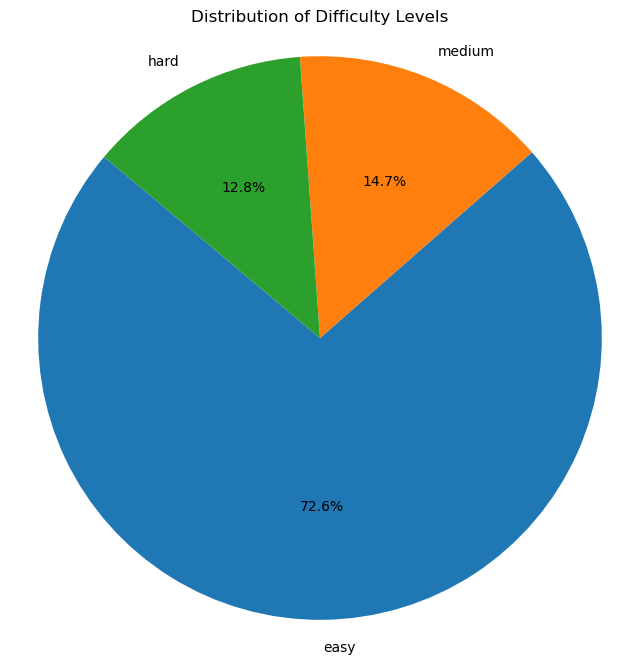

In [133]:
#make a pie chart of the distribution of difficulty levels
plt.figure(figsize=(8, 8))
plt.pie(difficulty_counts.values, labels=difficulty_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Difficulty Levels")
plt.axis("equal")
plt.show()

- Describing response time

In [134]:
df["Response Time"].describe()

count    17340.000000
mean     18913.771799
std       6608.463551
min       6361.000000
25%      14174.000000
50%      16575.000000
75%      23808.000000
max      46882.000000
Name: Response Time, dtype: float64

# 2. Feature engineering & Target creation

- In this section we'll engineer the features needed for the knowledge estimatior in order to predict correctly the student level.
  - Note : The following created features are cummulative and computed up to the current row in order to ensure that no data leakage happens

| Feature | Description |
|---|---|
| `global_correctness` | Overall accuracy so far (cumulative)  => running mean of `correct` column up to current interaction |
| `topic_correctness` | Accuracy within the current question's topic (cumulative) => mean of `correct` for same topic up to current row |
| `easy_correct_avg` | Accuracy on easy questions (cumulative) => mean of `correct` for difficulty='easy' up to current row |
| `medium_correct_avg` | Same as as for easy but for `medium` |
| `hard_correct_avg` | Same as as for easy but for `hard` |
| `avg_response_time` | Rolling mean of `Response Time` so far => cumulative average response time in milliseconds |
| `questions_answered_so_far` | Count of interactions before current row => total questions seen by student up to this point |
| `difficulty_encoded` | Current question's difficulty as integer: Easy=1, Medium=2, Hard=3 |

The **Target** would be a 3-class knowledge level (Beginner, Intermediate, Advanced) 

### 2.1 Sorting by the student ID while preserving the same order of interactions

In [135]:
df_sorted = df.sort_values(
    by=['Student ID'],
    kind='stable'          # stable sort preserves original row order within each student group
).reset_index(drop=True)


### 2.2 Creating the function to compute all the cummulative features 

- Note that the fallback values for the accuracy metrics are 0.5 to represent neutal state (50-50 chance)

In [136]:
def compute_features(df,row_idx):
    current_student=df.loc[row_idx, 'Student ID']
    current_topic=df.loc[row_idx, 'topic']
    current_difficulty=df.loc[row_idx, 'difficulty']
    difficulty_map={"easy": 1, "medium": 2, "hard": 3}
    encoded_difficulty=difficulty_map.get(current_difficulty, 2)

    student_history = df[(df['Student ID'] == current_student) & (df.index < row_idx)]

    if len(student_history)==0:
        return{
            'global_correctness': 0.5,
            'topic_correctness': 0.5,
            'easy_correct_avg': 0.5,
            'medium_correct_avg': 0.5,
            'hard_correct_avg': 0.5,
            'avg_response_time': 0.0,
            'questions_answered_so_far': 0,
            'encoded_difficulty': encoded_difficulty
        }
    
    global_correctness = student_history['correct'].mean()
    topic_history=student_history[student_history['topic']==current_topic]
    topic_correctness=topic_history['correct'].mean() if len(topic_history)>0 else 0.5
    easy_correct_avg=student_history[student_history['difficulty']=='easy']['correct'].mean() if len(student_history[student_history['difficulty']=='easy'])>0 else 0.5
    medium_correct_avg=student_history[student_history['difficulty']=='medium']['correct'].mean() if len(student_history[student_history['difficulty']=='medium'])>0 else 0.5
    hard_correct_avg=student_history[student_history['difficulty']=='hard']['correct'].mean() if len(student_history[student_history['difficulty']=='hard'])>0 else 0.5
    avg_response_time=student_history['Response Time'].mean()
    questions_answered_so_far=len(student_history)

    return{
        'global_correctness': global_correctness,
        'topic_correctness': topic_correctness,
        'easy_correct_avg': easy_correct_avg,
        'medium_correct_avg': medium_correct_avg,
        'hard_correct_avg': hard_correct_avg,
        'avg_response_time': avg_response_time,
        'questions_answered_so_far': questions_answered_so_far,
        'encoded_difficulty': encoded_difficulty
    }


### 2.3 Calculating the features

- The above created function would be used in real time testing nd could not be used for filling all the rows in our dataset for training(because of high complexity)

- The following will create all the cummulative features for our dataset 

In [137]:
print("Computing cumulative features (vectorised)...")
# Work on a copy sorted stably by Student ID (interaction order preserved)
df_feat = df_sorted.copy()

# ── 1. difficulty_encoded (Current question property) ─────────────────────────
difficulty_map = {"easy": 1, "medium": 2, "hard": 3}
df_feat['difficulty_encoded'] = df_feat['difficulty'].map(difficulty_map).fillna(2).astype(int)

# ── Helper: cumulative mean shifted by 1 ──────────────────────────────────────
def shifted_expanding_mean(series, fill_val=0.5):
    # expanding().mean() calculates mean from 0..i
    # .shift(1) moves it so row i sees mean of 0..i-1
    return series.expanding().mean().shift(1).fillna(fill_val)

# ── 2. global_correctness ─────────────────────────────────────────────────────
df_feat['global_correctness'] = (
    df_feat.groupby('Student ID')['correct']
    .transform(lambda x: shifted_expanding_mean(x, 0.5))
)

# ── 3. avg_response_time ──────────────────────────────────────────────────────
df_feat['avg_response_time'] = (
    df_feat.groupby('Student ID')['Response Time']
    .transform(lambda x: shifted_expanding_mean(x, 0.0))
)

# ── 4. questions_answered_so_far ──────────────────────────────────────────────
df_feat['questions_answered_so_far'] = (
    df_feat.groupby('Student ID').cumcount()
)

# ── 5. topic_correctness ──────────────────────────────────────────────────────
df_feat['topic_correctness'] = (
    df_feat.groupby(['Student ID', 'topic'])['correct']
    .transform(lambda x: shifted_expanding_mean(x, 0.5))
)

# ── 6. easy_correct_avg / medium_correct_avg / hard_correct_avg ───────────────
for diff_val in ['easy', 'medium', 'hard']:
    col_name = f'{diff_val}_correct_avg'
    
    # Create a temporary series: correct value if difficulty matches, else NaN
    # expanding().mean() automatically ignores NaNs
    df_feat[col_name] = (
        df_feat.assign(temp_corr=np.where(df_feat['difficulty'] == diff_val, df_feat['correct'], np.nan))
        .groupby('Student ID')['temp_corr']
        .transform(lambda x: shifted_expanding_mean(x, 0.5))
    )

# ── 7. topic_familiarity (Has the student seen this topic before?) (This will be used fot the correctness prediction model) ──────────────────────────────────────────────
df_feat['topic_questions_seen'] = (
    df_feat.groupby(['Student ID', 'topic']).cumcount())
df_feat['topic_familiarity'] = (df_feat['topic_questions_seen'] > 0).astype(int)
# Verification
feat_cols = [
    'Student ID', 'difficulty_encoded', 'global_correctness', 'topic_correctness', 
    'easy_correct_avg', 'medium_correct_avg', 
    'hard_correct_avg', 'avg_response_time', 'questions_answered_so_far'
]

print(f"\nSample (first 5 rows):")
print(df_feat[feat_cols].head().to_string())

Computing cumulative features (vectorised)...

Sample (first 5 rows):
     Student ID  difficulty_encoded  global_correctness  topic_correctness  easy_correct_avg  medium_correct_avg  hard_correct_avg  avg_response_time  questions_answered_so_far
0  0Hpj01paAdfZ                   3            0.500000           0.500000          0.500000                 0.5               0.5               0.00                          0
1  0Hpj01paAdfZ                   1            0.000000           0.500000          0.500000                 0.5               0.0           24498.00                          1
2  0Hpj01paAdfZ                   1            0.500000           1.000000          1.000000                 0.5               0.0           16362.50                          2
3  0Hpj01paAdfZ                   1            0.333333           0.500000          0.500000                 0.5               0.0           16416.00                          3
4  0Hpj01paAdfZ                   2          

### 2.4 Deriving the target feature ``Level``

 score = (W1 * global_correctness) + (W2 * hard_correct_avg) - (W3 * avg_response_time) 

- Note: avg_response_time is inverted and normalized so higher is better to pinalize guessing

In [138]:
def derive_label(df, w1=0.5, w2=0.3, w3=0.2):
    
    # 1. Extract the Final State for each student to define their "True Level"
    student_final_state = df.groupby('Student ID').agg({
        'global_correctness': 'last',
        'hard_correct_avg': 'last',
        'avg_response_time': 'last'
    })

    # 2. Normalize Response Time (Inverted)
    # 1.0 = Fastest student, 0.0 = Slowest student
    t_min = student_final_state['avg_response_time'].min()
    t_max = student_final_state['avg_response_time'].max()
    student_final_state['normalized_inv_time'] = 1 - (
        (student_final_state['avg_response_time'] - t_min) / (t_max - t_min + 1e-9)
    )

    # 3. Calculate Final Mastery Score
    student_final_state['score'] = (
        (w1 * student_final_state['global_correctness']) +
        (w2 * student_final_state['hard_correct_avg']) +
        (w3 * student_final_state['normalized_inv_time'])
    )

    # 4. Create 3-class Labels using Percentiles (Quantiles) for balanced distribution
    student_final_state['knowledge_level'] = pd.qcut(
        student_final_state['score'],
        q=3,
        labels=['Beginner', 'Intermediate', 'Advanced']
    )

    return student_final_state[['score', 'knowledge_level']]


### - An alternative for deriving the level
 - Calculating the score directly

In [139]:
# def derive_correct_only_score(df):
#     student_score = df.groupby('Student ID')['correct'].agg(
#         correct_count='sum',
#         total_questions='count'
#     )

#     student_score['correct_rate'] = (
#         student_score['correct_count'] / student_score['total_questions']
#     )
    
#     # Assign knowledge levels based on correct_rate using quantiles
#     student_score['knowledge_level'] = pd.qcut(
#         student_score['correct_rate'],
#         q=3,
#         labels=['Beginner', 'Intermediate', 'Advanced'],
#         duplicates='drop'  # Handle cases where quantiles overlap
#     )

#     return student_score[['correct_count', 'correct_rate', 'knowledge_level']]

- Creating the labels

In [140]:
print("Creating target")
labels_df = derive_label(df_feat)

# Merge the labels back to the interaction-level data
# Now every interaction for Student X has the target: 'knowledge_level'
df_final = df_feat.merge(labels_df, on='Student ID')

# --- DATASET SUMMARY ---
print(f"Final dataset shape: {df_final.shape}")
print("\nClass Distribution (Balanced by Percentiles):")
print(df_final['knowledge_level'].value_counts(normalize=True))

# Preview a few students to see their different snapshots pointing to one final level
print("\nSample of snapshots for one student:")
print(df_final[['Student ID', 'questions_answered_so_far', 'global_correctness', 'knowledge_level']].head(5))

# Save the master file for training
df_final.to_csv('interactions_final.csv', index=False)

Creating target
Final dataset shape: (17340, 18)

Class Distribution (Balanced by Percentiles):
knowledge_level
Intermediate    0.33564
Beginner        0.33218
Advanced        0.33218
Name: proportion, dtype: float64

Sample of snapshots for one student:
     Student ID  questions_answered_so_far  global_correctness knowledge_level
0  0Hpj01paAdfZ                          0            0.500000        Beginner
1  0Hpj01paAdfZ                          1            0.000000        Beginner
2  0Hpj01paAdfZ                          2            0.500000        Beginner
3  0Hpj01paAdfZ                          3            0.333333        Beginner
4  0Hpj01paAdfZ                          4            0.500000        Beginner


# 3. Data splitting 

- We use GroupShuffleSplit in order to keeep all the interactions of a student in only train or test
- This have no risk of data leakage

In [141]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# --- STEP 1: SPLIT BY STUDENT ---
# 80% of students for training, 20% for testing
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

# Using df_final which contains our features and the MDPI label
train_idx, test_idx = next(gss.split(df_final, groups=df_final['Student ID']))

train_df = df_final.iloc[train_idx]
test_df = df_final.iloc[test_idx]

# --- STEP 2: PREPARE FEATURES (X) AND TARGET (y) ---
# We exclude non-numeric IDs and the raw 'correct' answer for this specific model
features = [
    'global_correctness', 'topic_correctness',
    'easy_correct_avg', 'medium_correct_avg', 'hard_correct_avg',
    'avg_response_time', 'questions_answered_so_far', 'difficulty_encoded'
]
X_train = train_df[features]
y_train = train_df['knowledge_level']

X_test = test_df[features]
y_test = test_df['knowledge_level']

# --- STEP 3: SCALE THE DATA ---
# Important for Logistic Regression (especially for response_time vs correctness)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training on {train_df['Student ID'].nunique()} students ({len(X_train)} interactions)")
print(f"Testing on {test_df['Student ID'].nunique()} students ({len(X_test)} interactions)")

Training on 96 students (13710 interactions)
Testing on 25 students (3630 interactions)


# 4. Model training (Knowledge Estimator)

In [142]:

models = {
    "Logistic Regression": LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_SEED
    ),
    "Decision Tree": CalibratedClassifierCV(
        DecisionTreeClassifier(
            max_depth=6,
            class_weight='balanced',
            random_state=RANDOM_SEED
        ),
        cv=5, method='sigmoid'
    ),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        class_weight='balanced',
        random_state=RANDOM_SEED
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=RANDOM_SEED
    ),
}

# ── Train and evaluate (non-XGBoost models) ────────────────────────────────────
results = {}

print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'Brier Score':>12}")
print("-" * 60)

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    
    y_pred      = clf.predict(X_test_scaled)
    y_proba_full = clf.predict_proba(X_test_scaled)
    
    acc         = accuracy_score(y_test, y_pred)
    auc         = roc_auc_score(y_test, y_proba_full, multi_class='ovr', labels=np.unique(y_test))
    brier       = brier_score_loss(y_test, y_proba_full, labels=np.unique(y_test))
    
    results[name] = {
        'model': clf, 'accuracy': acc,
        'roc_auc': auc, 'brier': brier,
        'y_pred': y_pred, 'y_proba': y_proba_full
    }
    
    print(f"{name:<25} {acc:>10.3f} {auc:>10.3f} {brier:>12.4f}")

# ── Train and evaluate XGBoost (requires label encoding) ────────────────────────
le_xgb = LabelEncoder()
y_train_encoded = le_xgb.fit_transform(y_train)
y_test_encoded = le_xgb.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    verbosity=0,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_scaled, y_train_encoded)
y_pred_xgb_encoded = xgb_model.predict(X_test_scaled)
y_pred_xgb = le_xgb.inverse_transform(y_pred_xgb_encoded)
y_proba_xgb_full = xgb_model.predict_proba(X_test_scaled)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test_encoded, y_proba_xgb_full, multi_class='ovr', labels=np.arange(len(le_xgb.classes_)))
brier_xgb = brier_score_loss(y_test_encoded, y_proba_xgb_full, labels=np.arange(len(le_xgb.classes_)))

results['XGBoost'] = {
    'model': xgb_model,
    'accuracy': acc_xgb,
    'roc_auc': auc_xgb,
    'brier': brier_xgb,
    'y_pred': y_pred_xgb,
    'y_proba': y_proba_xgb_full
}

print(f"{'XGBoost':<25} {acc_xgb:>10.3f} {auc_xgb:>10.3f} {brier_xgb:>12.4f}")

# ── Identify best model ────────────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\nBest model by ROC-AUC: {best_name} ({results[best_name]['roc_auc']:.3f})")
print(f"Best model by Accuracy: {max(results, key=lambda k: results[k]['accuracy'])} ({max(results[k]['accuracy'] for k in results):.3f})")

Model                       Accuracy    ROC-AUC  Brier Score
------------------------------------------------------------
Logistic Regression            0.680      0.832       0.4765
Decision Tree                  0.580      0.719       0.5585
Naive Bayes                    0.548      0.733       0.5939
Random Forest                  0.609      0.760       0.5010
Gradient Boosting              0.546      0.740       0.5892
XGBoost                        0.567      0.744       0.5578

Best model by ROC-AUC: Logistic Regression (0.832)
Best model by Accuracy: Logistic Regression (0.680)


Since we are building an Active Learning system, a 0.68 accuracy is actually perfect.

Why? Because when the model predicts "Intermediate" with low confidence, that is exactly where the Uncertainty Sampling shines. The system will say: "I'm not sure if this student is Intermediate or Advanced... let me give them a Hard question to find out."

### Features importance

              global_correctness  topic_correctness  easy_correct_avg  \
Advanced               -0.219311          -0.003213          0.689792   
Beginner                0.273605           0.012340         -0.752057   
Intermediate           -0.054295          -0.009127          0.062265   

              medium_correct_avg  hard_correct_avg  avg_response_time  \
Advanced                0.207509          0.834538          -0.516503   
Beginner               -0.096810         -1.126368           0.625712   
Intermediate           -0.110699          0.291831          -0.109209   

              questions_answered_so_far  difficulty_encoded  
Advanced                       0.131123           -0.008382  
Beginner                      -0.046073            0.018459  
Intermediate                  -0.085050           -0.010077  
hard_correct_avg             0.291831
easy_correct_avg             0.062265
topic_correctness           -0.009127
difficulty_encoded          -0.010077
global_correct

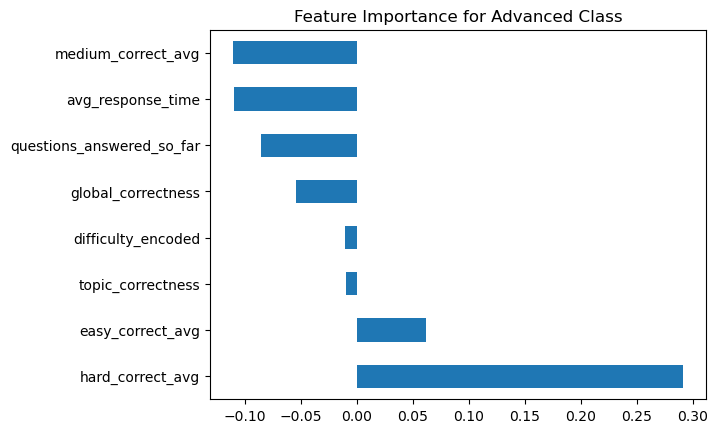

In [143]:
# Extract the best model object
best_model_obj = results[best_name]['model']

# Extract coefficients for all classes
coef_df = pd.DataFrame(
    best_model_obj.coef_,
    index=best_model_obj.classes_,
    columns=features
)

# View feature importance for each class
print(coef_df)

# Or focus on one class (e.g., Advanced - index 2)
importances = pd.Series(best_model_obj.coef_[2], index=features).sort_values(ascending=False)
print(importances)

# Visualize
importances.plot(kind='barh', title='Feature Importance for Advanced Class')
plt.show()

### - An exemple of usage

In [ ]:
example_probs = best_model_obj.predict_proba(X_test_scaled[10].reshape(1, -1))

print("--- Model Confidence (The Active Learning Engine) ---")
for level, prob in zip(best_model_obj.classes_, example_probs[0]):
    print(f"{level}: {prob*100:.1f}%")

# Uncertainty Calculation
uncertainty = 1 - np.max(example_probs)
print(f"\nModel Uncertainty: {uncertainty:.2f}")

--- Model Confidence (The Active Learning Engine) ---
Advanced: 0.8%
Beginner: 84.4%
Intermediate: 14.8%

Model Uncertainty: 0.16


### Saving the best model

In [146]:
# Create the models directory if it doesn't exist
from pathlib import Path
Path('../models').mkdir(exist_ok=True)

# Save the best model (Gradient Boosting) to disk
best_model = results[best_name]['model']
model_path = '../models/knowledge_estimator.pkl'

joblib.dump(best_model, model_path)
print(f"Best model ({best_name}) saved to {model_path}")

# Also save the scaler for preprocessing new data
scaler_path = '../models/knowledge_estimator_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save feature names for reference
features_path = '../models/knowledge_estimator_features.pkl'
joblib.dump(features, features_path)
print(f"Feature names saved to {features_path}")

Best model (Logistic Regression) saved to ../models/knowledge_estimator.pkl
Scaler saved to ../models/knowledge_estimator_scaler.pkl
Feature names saved to ../models/knowledge_estimator_features.pkl


# 5. Model training (Correctness predictor)

### 5.1 Splitting the data

In [90]:

gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

# Using df_final which contains our features and the MDPI label
train_idx, test_idx = next(gss.split(df_final, groups=df_final['Student ID']))

CP_train_df = df_final.iloc[train_idx]
CP_test_df = df_final.iloc[test_idx]

# --- STEP 2: PREPARE FEATURES (X) AND TARGET (y) ---
# We exclude non-numeric IDs and the raw 'correct' answer for this specific model
features = [
    'global_correctness', 'topic_correctness',
    'easy_correct_avg', 'medium_correct_avg', 'hard_correct_avg',
    'avg_response_time', 'questions_answered_so_far', 'difficulty_encoded','topic_familiarity'
]
X_train = CP_train_df[features]
y_train = CP_train_df['correct']

X_test = CP_test_df[features]
y_test = CP_test_df['correct']

# --- STEP 3: SCALE THE DATA ---
# Important for Logistic Regression (especially for response_time vs correctness)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training on {CP_train_df['Student ID'].nunique()} students ({len(X_train)} interactions)")
print(f"Testing on {CP_test_df['Student ID'].nunique()} students ({len(X_test)} interactions)")

Training on 96 students (13710 interactions)
Testing on 25 students (3630 interactions)


### 5.2 Training the condidate models

In [91]:
# ── Define all models ─────────────────────────────────────────────────────────
RANDOM_SEED = 42
models = {
    "Logistic Regression": LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_SEED
    ),
    "Decision Tree": CalibratedClassifierCV(
        # DecisionTree doesn't produce calibrated probabilities natively
        # — wrapping with CalibratedClassifierCV fixes this
        DecisionTreeClassifier(
            max_depth=6,
            class_weight='balanced',
            random_state=RANDOM_SEED
        ),
        cv=5, method='sigmoid'
    ),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        class_weight='balanced',
        random_state=RANDOM_SEED
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=RANDOM_SEED
    ),
}

# ── Train and evaluate ────────────────────────────────────────────────────────
results = {}

print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'Brier Score':>12}")
print("-" * 60)

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    
    y_pred      = clf.predict(X_test_scaled)
    y_proba     = clf.predict_proba(X_test_scaled)[:, 1]  # P(correct=1)
    
    acc         = accuracy_score(y_test, y_pred)
    auc         = roc_auc_score(y_test, y_proba)
    brier       = brier_score_loss(y_test, y_proba)
    
    results[name] = {
        'model': clf, 'accuracy': acc,
        'roc_auc': auc, 'brier': brier,
        'y_pred': y_pred, 'y_proba': y_proba
    }
    
    print(f"{name:<25} {acc:>10.3f} {auc:>10.3f} {brier:>12.4f}")

# Pick best model by ROC-AUC (most important for probability quality)
best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\nBest model by ROC-AUC: {best_name} ({results[best_name]['roc_auc']:.3f})")

Model                       Accuracy    ROC-AUC  Brier Score
------------------------------------------------------------
Logistic Regression            0.838      0.849       0.1405
Decision Tree                  0.844      0.849       0.1069
Naive Bayes                    0.852      0.845       0.1149
Random Forest                  0.839      0.872       0.1309
Gradient Boosting              0.861      0.875       0.1009

Best model by ROC-AUC: Gradient Boosting (0.875)


### 5.3 features importance 

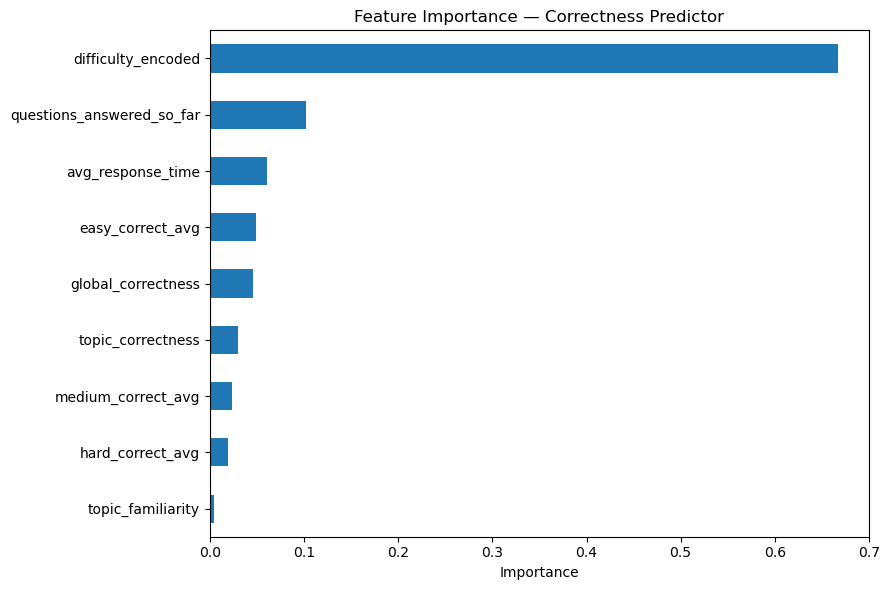

In [92]:
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=features).sort_values()

ax = importances.plot(kind="barh", figsize=(9, 6), title="Feature Importance — Correctness Predictor")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


### 5.4 Saving the best model

In [93]:
# Create the models directory if it doesn't exist
from pathlib import Path
Path('../models').mkdir(exist_ok=True)

# Save the best model (Gradient Boosting) to disk
best_model = results[best_name]['model']
model_path = '../models/correctness_predictor.pkl'

joblib.dump(best_model, model_path)
print(f"Best model ({best_name}) saved to {model_path}")

# Also save the scaler for preprocessing new data
scaler_path = '../models/correctness_predictor_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save feature names for reference
features_path = '../models/correctness_predictor_features.pkl'
joblib.dump(features, features_path)
print(f"Feature names saved to {features_path}")

Best model (Gradient Boosting) saved to ../models/correctness_predictor.pkl
Scaler saved to ../models/correctness_predictor_scaler.pkl
Feature names saved to ../models/correctness_predictor_features.pkl
